# Aula 6 — Detecção de Outliers e Anomalias

**Ferramentas:** NumPy, Pandas, scikit-learn, PyOD, PyTorch

## Instalação e Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from pyod.models.lof import LOF

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)
print('Ambiente configurado com sucesso!')

Ambiente configurado com sucesso!


## Geração do Dataset Sintético

Dataset sintético de transações financeiras com anomalias injetadas de forma controlada

In [2]:
N_NORMAL = 400
N_ANOMALIA = 20

# Dados normais
normais = np.random.randn(N_NORMAL, 2)
normais[:, 0] = normais[:, 0] * 200 + 500
normais[:, 1] = normais[:, 1] * 2 + 10

# Anomalias de ponto (bem separadas)
anomalias = np.random.uniform(low=1200, high=2000, size=(N_ANOMALIA, 2))

X = np.vstack([normais, anomalias])
y = np.array([0] * N_NORMAL + [1] * N_ANOMALIA)

df = pd.DataFrame(X, columns=['valor_transacao', 'frequencia_diaria'])
df['anomalia_real'] = y

print(f'Dataset total: {len(df)} linhas')
print(df.head())

print('\nAmostra de registros com anomalia_real = 1:')
print(df[df['anomalia_real'] == 1].sample(5, random_state=42))

Dataset total: 420 linhas
   valor_transacao  frequencia_diaria  anomalia_real
0       599.342831           9.723471              0
1       629.537708          13.046060              0
2       453.169325           9.531726              0
3       815.842563          11.534869              0
4       406.105123          11.085120              0

Amostra de registros com anomalia_real = 1:
     valor_transacao  frequencia_diaria  anomalia_real
400      1455.280379        1863.132379              1
417      1814.618731        1534.213426              1
415      1583.900496        1702.004371              1
401      1229.606108        1677.015903              1
408      1908.782199        1692.690551              1


### Observação
- O rótulo `anomalia_real` existe **apenas para avaliação final**.
- Nenhum algoritmo abaixo deve usar `y` para treinar ou calibrar thresholds.

## Separação Treino/Teste

In [3]:
idx = np.random.permutation(len(X))
X_shuf = X[idx]
y_shuf = y[idx]

n_train = int(0.7 * len(X_shuf))
X_train, X_test = X_shuf[:n_train], X_shuf[n_train:]
y_train, y_test = y_shuf[:n_train], y_shuf[n_train:]

print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')
print(f'Taxa de anomalia no treino: {y_train.mean():.2%}')
print(f'Taxa de anomalia no teste: {y_test.mean():.2%}')

Treino: 294 | Teste: 126
Taxa de anomalia no treino: 4.76%
Taxa de anomalia no teste: 4.76%


### Observação
- Primeiro dividimos os dados; só depois ajustamos scaler, limiares e modelos.
- Isso evita contaminação de estatísticas do teste no treinamento.

## Pré-processamento com Escalonamento

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Scaler ajustado no treino e aplicado no teste com sucesso.')

Scaler ajustado no treino e aplicado no teste com sucesso.


## Métodos Estatísticos

In [5]:
from scipy.stats import zmap, iqr

def zscore_predict(train_col, test_col, limiar=3.0):
    z = zmap(test_col, train_col)
    return (np.abs(z) > limiar).astype(int)

def iqr_predict(train_col, test_col, k=1.5):
    q1, q3 = np.percentile(train_col, [25, 75])
    iqr_val = iqr(train_col)
    low = q1 - k * iqr_val
    high = q3 + k * iqr_val
    return ((test_col < low) | (test_col > high)).astype(int)

z0 = zscore_predict(X_train[:, 0], X_test[:, 0], limiar=3.0)
z1 = zscore_predict(X_train[:, 1], X_test[:, 1], limiar=3.0)
y_pred_z = ((z0 == 1) | (z1 == 1)).astype(int)

i0 = iqr_predict(X_train[:, 0], X_test[:, 0], k=1.5)
i1 = iqr_predict(X_train[:, 1], X_test[:, 1], k=1.5)
y_pred_iqr = ((i0 == 1) | (i1 == 1)).astype(int)

print('Predições estatísticas prontas (thresholds aprendidos no treino para evitar vazamento).')

Predições estatísticas prontas (thresholds aprendidos no treino para evitar vazamento).


### Observação
- O threshold do Z-score e do IQR foi obtido no treino e reaplicado no teste.
- Isso é o equivalente correto de uma validação fora da amostra para evitar vazamento de dados (data leakage).
- **Por que usamos `zmap` em vez de `zscore`?** A função padrão `zscore` padroniza os dados usando a média e o desvio padrão da *própria* amostra. Como precisamos padronizar os dados de teste usando a média e o desvio padrão aprendidos no conjunto de treino (para não haver vazamento), utilizamos a função `zmap` do `scipy.stats`. Ela faz exatamente isso: calcula o z-score de um array (teste) baseando-se nas estatísticas de outro array de referência (treino).

## LOF e Isolation Forest

In [ ]:
# Em produção, contamination deve ser estimada; aqui usamos um valor fixo por questões didáticas
contamination_estimada = 0.05

lof = LOF(n_neighbors=20, contamination=contamination_estimada)
lof.fit(X_train_s)
y_pred_lof = lof.predict(X_test_s).astype(int)

iforest = IsolationForest(
    n_estimators=200,
    contamination=contamination_estimada,
    random_state=42
)
iforest.fit(X_train_s)
y_if_raw = iforest.predict(X_test_s)
y_pred_if = np.where(y_if_raw == -1, 1, 0)

print('LOF e Isolation Forest executados sem usar rótulos no treino.')

LOF e Isolation Forest executados sem usar rótulos no treino.


### Observação
- Aqui `contamination` é uma **hipótese operacional**, não o valor real da base.
- Usar a taxa real de anomalia para ajustar modelo em produção configura vantagem irrealista.

## Autoencoder

In [7]:
def iqr_core_mask(X_arr, k=1.5):
    m0 = iqr_predict(X_arr[:, 0], X_arr[:, 0], k=k)
    m1 = iqr_predict(X_arr[:, 1], X_arr[:, 1], k=k)
    return (m0 == 0) & (m1 == 0)

core_mask = iqr_core_mask(X_train_s, k=1.5)
X_core = X_train_s[core_mask].astype(np.float32)

cut = int(0.8 * len(X_core))
X_ae_train = X_core[:cut]
X_ae_val = X_core[cut:]

class Autoencoder(nn.Module):
    def __init__(self, n_features=2, n_latent=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 8), nn.ReLU(),
            nn.Linear(8, 4), nn.ReLU(),
            nn.Linear(4, n_latent)
        )
        self.decoder = nn.Sequential(
            nn.Linear(n_latent, 4), nn.ReLU(),
            nn.Linear(4, 8), nn.ReLU(),
            nn.Linear(8, n_features)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = Autoencoder()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loader = DataLoader(TensorDataset(torch.from_numpy(X_ae_train)), batch_size=32, shuffle=True)

for epoch in range(40):
    model.train()
    for (batch,) in loader:
        opt.zero_grad()
        recon = model(batch)
        loss = loss_fn(recon, batch)
        loss.backward()
        opt.step()

model.eval()
with torch.no_grad():
    val_t = torch.from_numpy(X_ae_val.astype(np.float32))
    val_rec = model(val_t)
    err_val = ((val_t - val_rec) ** 2).mean(dim=1).numpy()

threshold_ae = np.percentile(err_val, 99)

with torch.no_grad():
    test_t = torch.from_numpy(X_test_s.astype(np.float32))
    test_rec = model(test_t)
    err_test = ((test_t - test_rec) ** 2).mean(dim=1).numpy()

y_pred_ae = (err_test > threshold_ae).astype(int)
print(f'Threshold AE (p99 em validação não rotulada): {threshold_ae:.4f}')

Threshold AE (p99 em validação não rotulada): 0.5846


## Avaliação no Conjunto de Teste

In [8]:
def metricas(y_true, y_pred):
    vp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    p = vp / (vp + fp) if (vp + fp) > 0 else 0.0
    r = vp / (vp + fn) if (vp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

preds = {
    'Z-score (2 vars)': y_pred_z,
    'IQR (2 vars)': y_pred_iqr,
    'LOF (scaled)': y_pred_lof,
    'Isolation Forest': y_pred_if,
    'Autoencoder': y_pred_ae
}

print(f"{'Método':<20} {'Detec.':>7} {'Precisão':>10} {'Recall':>9} {'F1':>9}")
print('-' * 60)
for nome, pred in preds.items():
    p, r, f1 = metricas(y_test, pred)
    print(f'{nome:<20} {pred.sum():>7} {p:>10.1%} {r:>9.1%} {f1:>9.1%}')

Método                Detec.   Precisão    Recall        F1
------------------------------------------------------------
Z-score (2 vars)           6     100.0%    100.0%    100.0%
IQR (2 vars)              10      60.0%    100.0%     75.0%
LOF (scaled)               6     100.0%    100.0%    100.0%
Isolation Forest           6     100.0%    100.0%    100.0%
Autoencoder                8      75.0%    100.0%     85.7%


/var/folders/23/mppdgbk11p14bwfystpnrfm40000gp/T/ipykernel_24317/2355751877.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=f1s, y=nomes, palette='viridis')


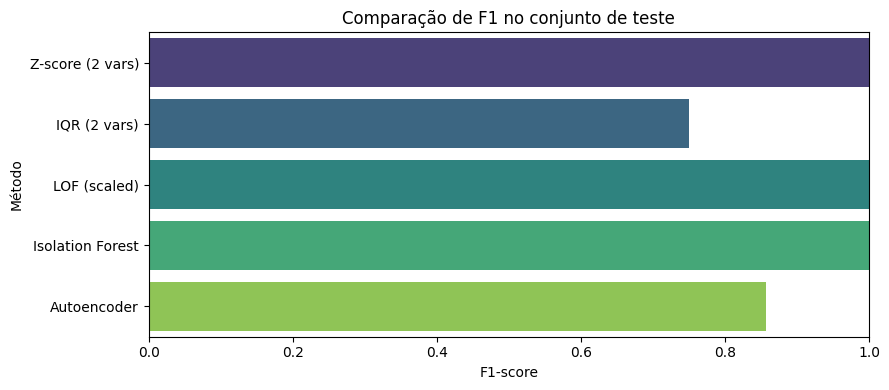

In [9]:
nomes = list(preds.keys())
f1s = [metricas(y_test, preds[n])[2] for n in nomes]

plt.figure(figsize=(9, 4))
sns.barplot(x=f1s, y=nomes, palette='viridis')
plt.xlim(0, 1.0)
plt.title('Comparação de F1 no conjunto de teste')
plt.xlabel('F1-score')
plt.ylabel('Método')
plt.tight_layout()
plt.show()

## Decisão Estratégica: Remover, Transformar ou Manter?

Identificar um outlier é apenas parte do problema. A decisão mais importante é **o que fazer com ele**.

### Quando remover
- Removemos quando há forte evidência de erro de medição, digitação ou integração de dados.
- Exemplos: idade igual a 250 anos, valor monetário negativo sem sentido de negócio, sensor com leitura impossível.
- Nesses casos, o valor extremo não representa um fenômeno real do processo, mas sim um erro no dado.

### Quando transformar
- Transformamos quando o valor é **legítimo**, mas sua magnitude extrema pode distorcer o treinamento do modelo.
- Uma estratégia clássica é o **winsorizing**, em que substituímos valores muito baixos e muito altos por limites como os percentis p5 e p95.
- Isso preserva a observação na base, mas reduz seu impacto desproporcional no aprendizado.

### Quando manter
- Mantemos o outlier quando ele representa exatamente o fenômeno que queremos estudar ou detectar.
- Exemplos: transações fraudulentas, falhas industriais, acessos anômalos em segurança, picos reais de demanda.
- Nesses contextos, remover o outlier seria apagar o sinal mais importante do problema.

In [10]:
from scipy.stats.mstats import winsorize

# 1. No Treino: Usamos a lib didaticamente para winsorizar
valor_original_treino = X_train[:, 0]
valor_transformado_treino = winsorize(valor_original_treino, limits=[0.05, 0.05])

# 2. No Teste: Precisamos fixar os limites aprendidos no treino para evitar data leakage
p5, p95 = np.percentile(valor_original_treino, [5, 95])
valor_transformado_teste = np.clip(X_test[:, 0], p5, p95)

print(f'Mínimo original (Treino): {valor_original_treino.min():.2f}')
print(f'Máximo original (Treino): {valor_original_treino.max():.2f}')
print(f'Mínimo após winsorizing (Treino): {valor_transformado_treino.min():.2f}')
print(f'Máximo após winsorizing (Treino): {valor_transformado_treino.max():.2f}')
print(f'Aplicação segura no Teste concluída com sucesso.')

Mínimo original (Treino): -148.25
Máximo original (Treino): 1951.25
Mínimo após winsorizing (Treino): 193.18
Máximo após winsorizing (Treino): 1115.78
Aplicação segura no Teste concluída com sucesso.


### Limitações
- Dataset simples e com anomalias extremas (cenário fácil).
- `contamination` é hipótese fixa; em produção deve ser estimada/monitorada.
- Para robustez, repetir experimento com múltiplas sementes e cenários de anomalia mais sutis.